In [1]:
# feature engineering dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
pd.set_option("display.max_columns",None)

In [3]:
df = pd.read_csv(r"D:\SecurePay-AI\dataset\feature_engineered\feature_engineered.csv")
df.head()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud,amount_category,large_transaction,sender_transaction_count,sender_transaction_amount,receiver_transaction_count,receiver_total_amount,receiver_fraud_count,receiver_fraud_rate,sender_balance_change,receiver_balance_change,balance_ratio,day,hour,night_transaction,receiver_risk_score,receiver_risk_level
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,Low,0,1,9839.64,1,9839.64,0.0,0.000000,9839.64,0.0,0.057834,0,1,1,0.177542,Very Low
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,Low,0,1,1864.28,1,1864.28,0.0,0.000000,1864.28,0.0,0.087731,0,1,1,0.177095,Very Low
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,Very Low,0,1,181.00,44,9922784.61,1.0,0.022727,181.00,0.0,0.994505,0,1,1,9.706460,Very Low
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,Very Low,0,1,181.00,41,18017212.53,1.0,0.024390,181.00,-21182.0,0.994505,0,1,1,9.728175,Very Low
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,Medium,0,1,11668.14,1,11668.14,0.0,0.000000,11668.14,0.0,0.280788,0,1,1,0.177644,Very Low


In [7]:
# receiver summary table

receiver_summary = (
    df.groupby("namedest")
    .agg(
          total_transactions=("namedest","count"),
          total_amount=("amount","sum"),
          average_amount=("amount","mean"),
          fraud_count=("isfraud","sum"),
          max_amount=("amount","max")
      )
    .reset_index()
)

receiver_summary.head()

,namedest,total_transactions,total_amount,average_amount,fraud_count,max_amount
0,C1000004082,6,2259324.39,376554.065000,0,1331742.99
1,C1000004940,13,2534004.05,194923.388462,0,556785.00
2,C1000013769,13,6204082.94,477237.149231,0,1606651.99
3,C100001587,9,1404313.66,156034.851111,0,481674.22
4,C1000015936,16,2267960.19,141747.511875,0,241817.38


In [9]:
receiver_summary.shape

(2722362, 6)

In [10]:
# fraud rate 

receiver_summary["fraud_rate"]=(
    receiver_summary["fraud_count"] /
    receiver_summary["total_transactions"]
)

receiver_summary.head()

,namedest,total_transactions,total_amount,average_amount,fraud_count,max_amount,fraud_rate
0,C1000004082,6,2259324.39,376554.065000,0,1331742.99,0.0
1,C1000004940,13,2534004.05,194923.388462,0,556785.00,0.0
2,C1000013769,13,6204082.94,477237.149231,0,1606651.99,0.0
3,C100001587,9,1404313.66,156034.851111,0,481674.22,0.0
4,C1000015936,16,2267960.19,141747.511875,0,241817.38,0.0


In [11]:
# normalize feature

receiver_summary["transaction_score"]=(
    receiver_summary["total_transactions"] /
    receiver_summary["total_transactions"].max()
)
receiver_summary["amount_score"]=(
    receiver_summary["total_amount"] /
    receiver_summary["total_amount"].max()
)
receiver_summary["fraud_score"]=(
    receiver_summary["fraud_rate"]
)

In [12]:
# receiver risk score

receiver_summary["receiver_risk_score"]=(
    receiver_summary["fraud_score"]*60
    + receiver_summary["transaction_score"]*20
    + receiver_summary["amount_score"]*20
)
receiver_summary["receiver_risk_score"]=(
    receiver_summary["receiver_risk_score"].round(2)
)

In [13]:
# assign risk level

receiver_summary["receiver_risk_level"]=pd.cut(
    receiver_summary["receiver_risk_score"],
    bins=[0,20,40,60,80,100],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ],
    include_lowest=True
)

In [14]:
# top resky reciver

receiver_summary.sort_values(
    "receiver_risk_score",
    ascending=False
).head(20)

,namedest,total_transactions,total_amount,average_amount,fraud_count,max_amount,fraud_rate,transaction_score,amount_score,fraud_score,receiver_risk_score,receiver_risk_level
181990,C1614528665,1,10000000.0,10000000.0,1,10000000.0,1.0,0.00885,0.027977,1.0,60.74,High
117405,C1396306912,1,10000000.0,10000000.0,1,10000000.0,1.0,0.00885,0.027977,1.0,60.74,High
385681,C36989160,1,10000000.0,10000000.0,1,10000000.0,1.0,0.00885,0.027977,1.0,60.74,High
216887,C1733297456,1,10000000.0,10000000.0,1,10000000.0,1.0,0.00885,0.027977,1.0,60.74,High
34316,C1115935121,1,10000000.0,10000000.0,1,10000000.0,1.0,0.00885,0.027977,1.0,60.74,High
238527,C1806199534,1,10000000.0,10000000.0,1,10000000.0,1.0,0.00885,0.027977,1.0,60.74,High
252255,C1852255407,1,10000000.0,10000000.0,1,10000000.0,1.0,0.00885,0.027977,1.0,60.74,High
510025,C790685338,1,10000000.0,10000000.0,1,10000000.0,1.0,0.00885,0.027977,1.0,60.74,High
271,C1000868784,1,10000000.0,10000000.0,1,10000000.0,1.0,0.00885,0.027977,1.0,60.74,High
458561,C617558864,1,10000000.0,10000000.0,1,10000000.0,1.0,0.00885,0.027977,1.0,60.74,High


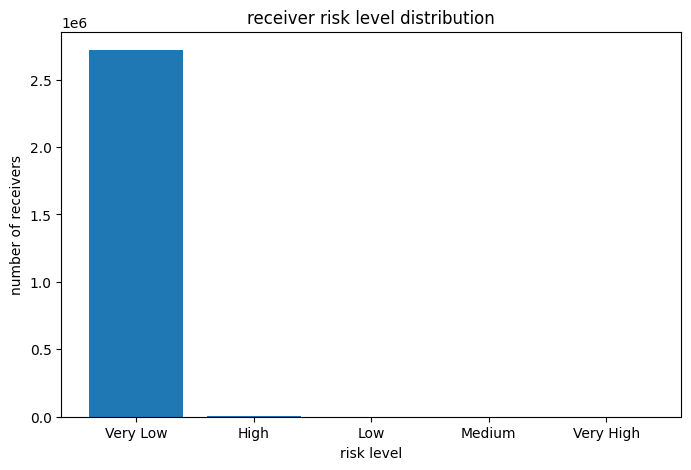

In [15]:
# visualization 

# risk level distribution 

risk_counts=receiver_summary["receiver_risk_level"].value_counts()
plt.figure(figsize=(8,5))
plt.bar(
    risk_counts.index.astype(str),
    risk_counts.values
)

plt.title("receiver risk level distribution")
plt.xlabel("risk level")
plt.ylabel("number of receivers")
plt.show()

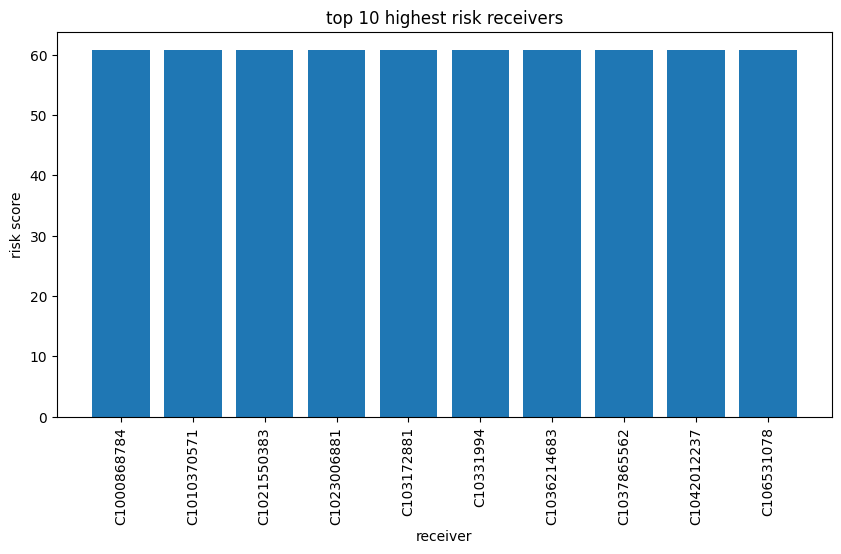

In [16]:
# top 10 highest risk receivers

top10=receiver_summary.nlargest(
    10,
    "receiver_risk_score"
)
plt.figure(figsize=(10,5))
plt.bar(
    top10["namedest"],
    top10["receiver_risk_score"]
)
plt.xticks(rotation=90)
plt.title("top 10 highest risk receivers")
plt.xlabel("receiver")
plt.ylabel("risk score")

plt.show()

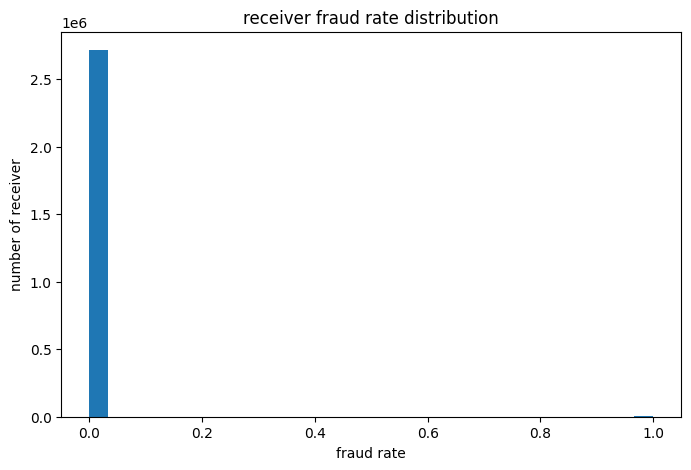

In [17]:
# fraud rate distribution 

plt.figure(figsize=(8,5))
plt.hist(
    receiver_summary["fraud_rate"],
    bins=30
)

plt.title("receiver fraud rate distribution")
plt.xlabel("fraud rate")
plt.ylabel("number of receiver")

plt.show()

In [18]:
# receiver risk table 
receiver_summary.to_csv(r"D:\SecurePay-AI\dataset\processed\receiver_risk_table.csv",index=False)

In [19]:
# receiver lookup function 

def check_receiver(receiver_id):
    result=receiver_summary[
        receiver_summary["namedest"]==receiver_id
    ]

    if result.empty:
        return "receiver not found..."

    return result[
        [
            "namedest",
            "receiver_risk_score",
            "receiver_risk_level",
            "fraud_count",
            "fraud_rate"
        ]
    ]

In [20]:
receiver_summary["namedest"].sample(1)

359287    C280751405
Name: namedest, dtype: object

In [21]:
check_receiver("C280751405")

,namedest,receiver_risk_score,receiver_risk_level,fraud_count,fraud_rate
359287,C280751405,0.39,Very Low,0,0.0
